<a href="https://colab.research.google.com/github/Lyna122/Vision/blob/main/Sentiment_analysis_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Install the datasets library
%pip install datasets

In [6]:
from datasets import load_dataset
import pandas as pd

# Load a dataset, for example, 'imdb' for sentiment analysis
# You can choose a different dataset and split as needed
dataset = load_dataset('imdb', split='train')

# Convert the dataset to a pandas DataFrame
# Ensure the column containing text data is named 'text' for compatibility with the existing sentiment analysis code
# The 'imdb' dataset has a 'text' column by default.
sentiment_df_real = pd.DataFrame(dataset)

# Display the first few rows of the loaded real data
display(sentiment_df_real.head())

# To use this new DataFrame for sentiment analysis, you'll need to replace the previous 'sentiment_df'
# with 'sentiment_df_real' in the sentiment analysis cell (c498017a).
# For example, change 'sentiment_df' to 'sentiment_df_real' in lines like:
# sentiment_df['polarity'] = sentiment_df['text'].apply(get_sentiment_polarity)
# to:
# sentiment_df_real['polarity'] = sentiment_df_real['text'].apply(get_sentiment_polarity)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [7]:
# Install TensorFlow if not already installed
%pip install tensorflow

print("TensorFlow installation complete.")

TensorFlow installation complete.


In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import numpy as np

# Define parameters for tokenization and padding
vocab_size = 10000
max_length = 120
oov_token = '<OOV>'

# Initialize Tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)

# Fit the tokenizer on the text data
texts = sentiment_df_real['text'].astype(str).tolist()
tokenizer.fit_on_texts(texts)

# Convert texts to sequences of integers
sequences = tokenizer.texts_to_sequences(texts)

# Pad sequences to a uniform length
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

# Convert labels to a NumPy array
labels = np.array(sentiment_df_real['label'])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)

print("Text tokenization, padding, label preparation, and data splitting complete.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Text tokenization, padding, label preparation, and data splitting complete.
Shape of X_train: (20000, 120)
Shape of y_train: (20000,)
Shape of X_test: (5000, 120)
Shape of y_test: (5000,)


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# Define model parameters (already defined in previous steps, but good to have them handy)
# vocab_size = 10000
# max_length = 120
embedding_dim = 128

# Initialize the Sequential model
model = Sequential()

# Add Embedding layer
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))

# Add Conv1D layer
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))

# Add GlobalMaxPooling1D layer
model.add(GlobalMaxPooling1D())

# Add Dense layer for classification
model.add(Dense(10, activation='relu'))

# Add Dropout layer for regularization
model.add(Dropout(0.5))

# Add the output Dense layer (binary classification, so 1 unit with sigmoid activation)
model.add(Dense(1, activation='sigmoid'))

# Print the model summary
model.summary()

print("CNN model architecture defined successfully.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

CNN model architecture defined successfully.


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# Define model parameters (already defined in previous steps, but good to have them handy)
# vocab_size = 10000
# max_length = 120
embedding_dim = 128

# Initialize the Sequential model
model = Sequential()

# Add Embedding layer
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))

# Add Conv1D layer
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))

# Add GlobalMaxPooling1D layer
model.add(GlobalMaxPooling1D())

# Add Dense layer for classification
model.add(Dense(10, activation='relu'))

# Add Dropout layer for regularization
model.add(Dropout(0.5))

# Add the output Dense layer (binary classification, so 1 unit with sigmoid activation)
model.add(Dense(1, activation='sigmoid'))

# Build the model explicitly to show parameters in the summary
# The input_shape for the first layer will be (None, max_length) where None is batch size.
model.build(input_shape=(None, max_length))

# Print the model summary
model.summary()

print("CNN model architecture defined successfully.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 120, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 116, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,363,349 (5.20 MB)

 Trainable params: 1,363,349 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

CNN model architecture defined successfully.


In [11]:
import tensorflow as tf

# Compile the model
# Using Adam optimizer, binary_crossentropy loss for binary classification,
# and accuracy as a metric.
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("CNN model compiled successfully.")

CNN model compiled successfully.


## Compile and Train CNN Model



In [12]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(X_test, y_test))

print("CNN model training complete.")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 81ms/step - accuracy: 0.6295 - loss: 0.6317 - val_accuracy: 0.8128 - val_loss: 0.4279
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.8378 - loss: 0.4194 - val_accuracy: 0.8368 - val_loss: 0.3842
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 77ms/step - accuracy: 0.9068 - loss: 0.2957 - val_accuracy: 0.8386 - val_loss: 0.3842
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.9480 - loss: 0.2005 - val_accuracy: 0.8432 - val_loss: 0.4384
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 77ms/step - accuracy: 0.9637 - loss: 0.1463 - val_accuracy: 0.8366 - val_loss: 0.5198
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.9739 - loss: 0.1094 - val_accuracy: 0.8380 - val_loss: 0.6153
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 87ms/step - accuracy: 0.9784 - loss: 0.0888 - val_accuracy: 0.8382 - val_loss: 0.6988
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 78ms/step - accuracy: 0.9812 - loss: 0.0783 - 

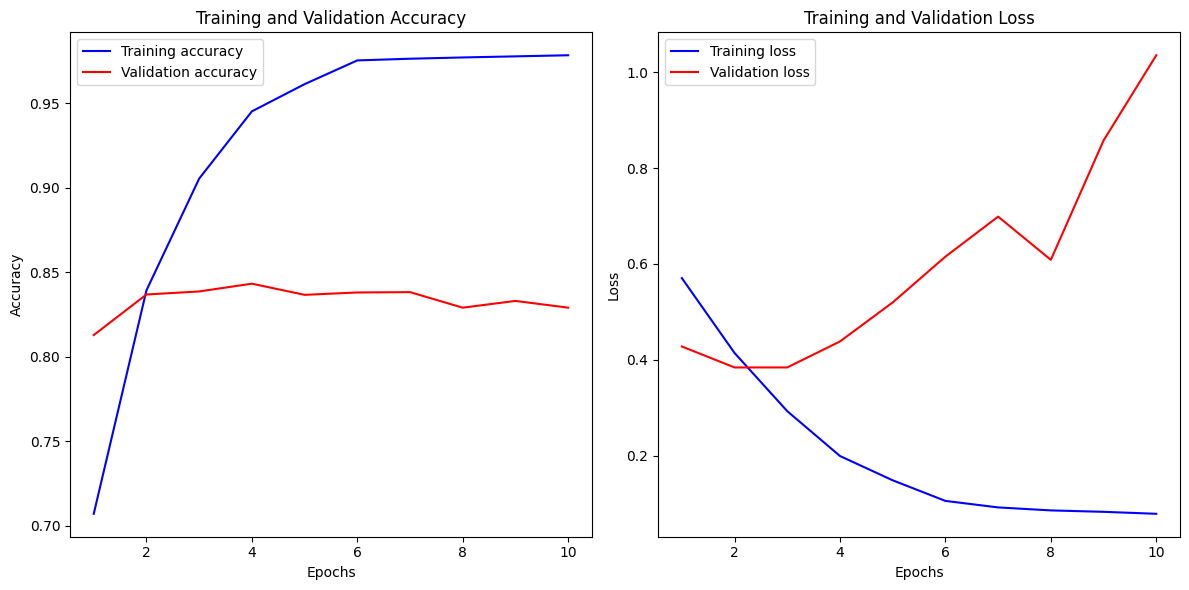

Training history plots generated successfully.


In [14]:
import matplotlib.pyplot as plt

# Get training and validation metrics from the history object
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(accuracy) + 1)

# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# Plot training and validation accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epochs, accuracy, 'b', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

print("Training history plots generated successfully.")

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

#Make predictions on the test set
y_pred_proba = model.predict(X_test)

#Convert predicted probabilities to binary class labels (threshold 0.5)
y_pred = (y_pred_proba > 0.5).astype(int)

#Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step
Accuracy: 0.8290
Precision: 0.8474
Recall: 0.8000
F1-Score: 0.8230


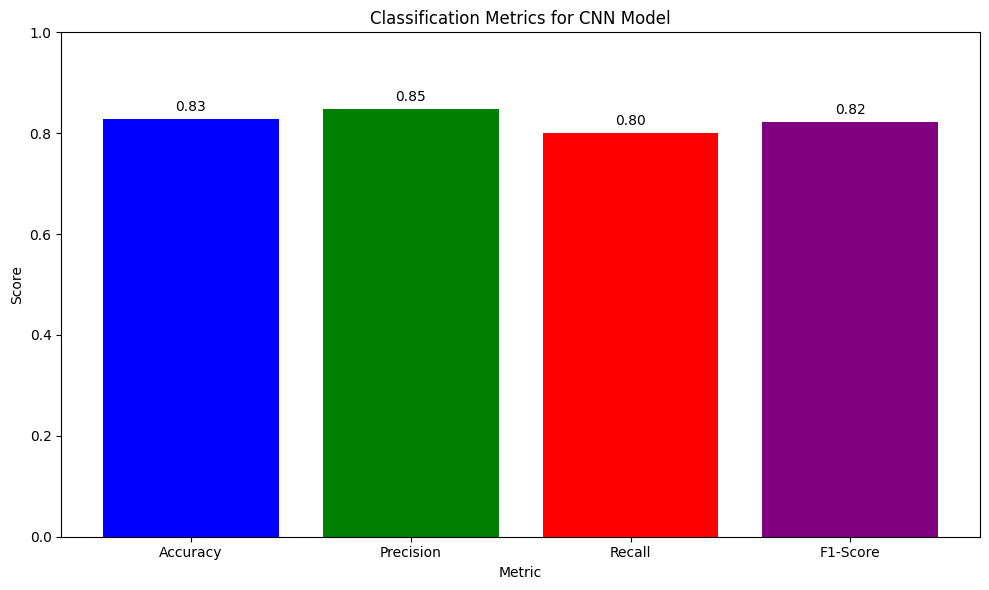

In [22]:
import matplotlib.pyplot as plt


metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}


plt.figure(figsize=(10, 6))
plt.bar(metrics.keys(), metrics.values(), color=['blue', 'green', 'red', 'purple'])

#title and labels
plt.title('Classification Metrics for CNN Model')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1)

#labels
for i, value in enumerate(metrics.values()):
    plt.text(i, value + 0.01, f'{value:.2f}', ha='center', va='bottom')

#Display
plt.tight_layout()
plt.show()



In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)



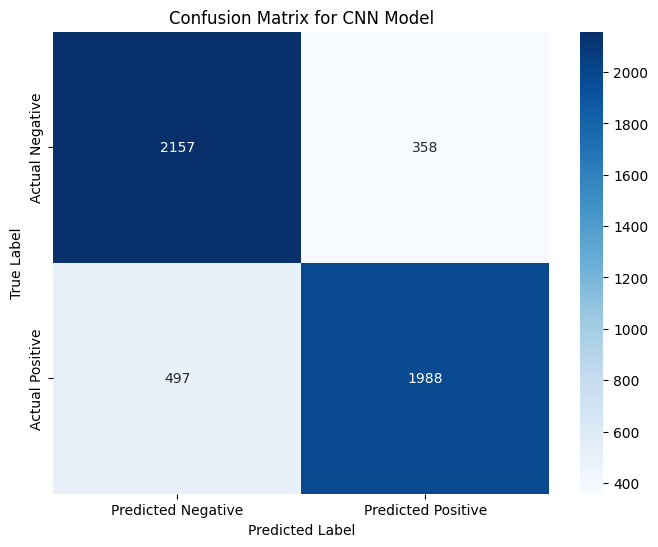

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for CNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

